The goal of the generator is to create “Fake Data” that resembles the “Real Data” using the “Noise Vectors”.
Whereas, the goal of the discriminator is to distinguish generated “Fake Data” from the “Real Data”.

# https://medium.com/@mnkrishn/gan-build-using-tensorflow-3d9ca7cef21f

In [10]:
! pip install tensorflow_datasets

  Using cached promise-2.3.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   - -------------------------------------- 0.2/5.1 MB 6.3 MB/s eta 0:00:01
   --- ------------------------------------ 0.5/5.1 MB 5.6 MB/s eta 0:00:01
   ------ --------------------------------- 0.8/5.1 MB 7.0 MB/s eta 0:00:01
   -------- ------------------------------- 1.1/5.1 MB 7.0 MB/s eta 0:00:01
   ----------- ---------------------------- 1.5/5.1 MB 7.3 MB/s eta 0:00:01
   --------------- ------------------------ 2.0/5.1 MB 8.6 MB/s eta 0:00:01
   ------------------ --------------------- 2.4/5.1 MB 8.5 MB/s eta 0:00:01
   ---------------------- ----------------- 2.8/5.1 MB 8.6 MB/s eta 0:00:01
   -------------------------- ------------- 3.3/5.1 MB 9.2 MB/s eta 0:00:01
   ----------------------------- ---------- 3.7/5.1 MB 9.2 MB/s eta 0:00:01
   ------------------------


[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


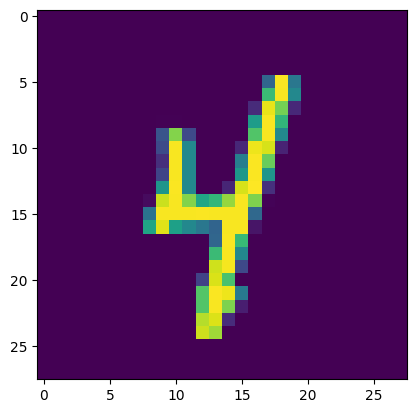

(28, 28, 1)


In [13]:
import tensorflow_datasets as tfds

from matplotlib import pyplot as plt

data, info = tfds.load("mnist", with_info=True)

# extract training data
train_data = data['train']

# Display 1 data
for example in train_data:
    image = example["image"]
    label = example["label"]
    plt.imshow(image)
    plt.show()
    print(image.shape)
    break

In [12]:
import tensorflow as tf
# Normalize Image between [-1,1]
def normalize(x):
    image = tf.cast(x['image'], tf.float32)
    image = (image / 127.5) - 1
    return image

In [31]:
class Discriminator(tf.keras.Model):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.flatten = tf.keras.layers.Flatten()
        self.dense_1 = tf.keras.layers.Dense(512, activation=tf.nn.leaky_relu )
        self.dense_2 = tf.keras.layers.Dense(256, activation=tf.nn.leaky_relu )
        self.dense_3 = tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu)
        self.dense_4 = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        x = self.flatten(inputs)
        x = self.dense_1(x)
        x = self.dense_2(x)
        x = self.dense_3(x)
        return self.dense_4(x)

In [32]:
class Generator(tf.keras.Model):
    def __init__(self):
        super(Generator, self).__init__()

        self.dense_1 = tf.keras.layers.Dense(128, activation=tf.nn.relu)
        self.dense_2 = tf.keras.layers.Dense(256, activation=tf.nn.relu)
        self.dense_3 = tf.keras.layers.Dense(512, activation=tf.nn.relu)
        self.dense_4 = tf.keras.layers.Dense(28 * 28)
        self.reshape = tf.keras.layers.Reshape((28, 28, 1))

    def call(self, inputs):
        x = self.dense_1(inputs)
        x = self.dense_2(x)
        x = self.dense_3(x)
        x = self.dense_4(x)
        return self.reshape(x)

In [33]:
class GAN(tf.keras.Model):
    # define the models
    def __init__(self, discriminator, generator, latent_dim):
        super(GAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
    
    # Define the compiler
    def compile(self, disc_optimizer, gen_optimizer, loss_fn, generator_loss, discriminator_loss):
        super(GAN, self).compile()
        self.disc_optimizer = disc_optimizer
        self.gen_optimizer = gen_optimizer
        self.generator_loss = generator_loss
        self.discriminator_loss = discriminator_loss
        self.loss_fn = loss_fn

        
    # @tf.function: The below function is completely Tensor Code
    # Good for optimization
    @tf.function
    # Modify Train step for GAN
    def train_step(self, images):
        batch_size = tf.shape(images)[0]
        noise = tf.random.normal([batch_size, self.latent_dim])

        # Define the loss function
        with tf.GradientTape(persistent=True) as tape:
            generated_images = self.generator(noise)
            real_output = self.discriminator(images)
            fake_output = self.discriminator(generated_images)
            
            gen_loss = self.generator_loss(self.loss_fn, fake_output)
            disc_loss = self.discriminator_loss(self.loss_fn, real_output, fake_output)

        # Calculate Gradient
        grad_disc = tape.gradient(disc_loss, self.discriminator.trainable_variables)
        grad_gen = tape.gradient(gen_loss, self.generator.trainable_variables)

        # Optimization Step: Update Weights & Learning Rate
        self.disc_optimizer.apply_gradients(zip(grad_disc, self.discriminator.trainable_variables))
        self.gen_optimizer.apply_gradients(zip(grad_gen, self.generator.trainable_variables))
        
        return {"Gen Loss ": gen_loss,"Disc Loss" : disc_loss}

In [34]:
# Save Image sample from Generator
# epoch: Number of epoch trained
# noise: latent vector
def save_imgs(epoch, generator, noise):
    gen_imgs = generator(noise)

    fig = plt.figure(figsize=(4, 4))

    for i in range(gen_imgs.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(gen_imgs[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    fig.savefig("images/mnist_%d.png" % epoch)

In [35]:
import os

In [36]:
# Tensorflow callbacks
class Training_Callback(tf.keras.callbacks.Callback):
    # Constructor
    def __init__(self, latent_dim, saving_rate):
        super(Training_Callback, self).__init__()
        self.latent_dim = latent_dim
        self.saving_rate = saving_rate
        
    # Save Image sample from Generator
    def save_imgs(self, epoch):
        # Number of images = 16
        seed = tf.random.normal([16, self.latent_dim])
        gen_imgs = self.model.generator(seed)
        
        fig = plt.figure(figsize=(4, 4))

        for i in range(gen_imgs.shape[0]):
            plt.subplot(4, 4, i + 1)
            plt.imshow(gen_imgs[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
            plt.axis('off')

        fig.savefig("images/mnist_%d.png" % epoch)
    
    # Called after each epoch
    def on_epoch_end(self, epoch, logs=None):
        # Save image after 50 epochs
        if epoch % 50 == 0:
            self.save_imgs(epoch)
        
        # Save Model every 100 epoch
        if epoch > 0 and epoch % self.saving_rate == 0:
            save_dir = "./models/model_epoch_" + str(epoch)
            
            # Create Directory to save file
            if not os.path.exists(save_dir):
                os.makedirs(save_dir)
            
            # Save weights
            self.model.discriminator.save_weights(save_dir + '/discriminator_%d' % epoch)
            self.model.generator.save_weights(save_dir + '/generator_%d' % epoch)

In [37]:
# Size of latent vector
latent_dim = 10
epochs = 1000
# Reduce Batch Size if GPU memory overflow
# Better Use Google Colab
batch_size = 2000
# Save model after every
saving_rate = 100

# Random Seed for Shuffling Data
buffer_size = 5000

# defining optimizer for Models
gen_optimizer = tf.keras.optimizers.Adam(0.0001)
disc_optimizer = tf.keras.optimizers.Adam(0.0001)

# Shuffle & Batch Data
train_dataset = train_data.map(normalize).shuffle(buffer_size , reshuffle_each_iteration=True).batch(batch_size)

# Define Loss Function
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [38]:
# Define the generator loss
def generator_loss(fake_output):
    # The generator wants the discriminator to think the fake images are real
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Define the discriminator loss
def discriminator_loss(real_output, fake_output):
    # The discriminator wants to correctly classify real images as real and fake images as fake
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [ ]:
# Create Discriminator & Generator
disc = Discriminator()
gen = Generator()

# Create compile model
gan = GAN(discriminator=disc, generator=gen, latent_dim=latent_dim)
gan.compile(
    disc_optimizer=disc_optimizer,
    gen_optimizer=gen_optimizer,
    loss_fn=cross_entropy,
    generator_loss = generator_loss,
    discriminator_loss = discriminator_loss
)

# Start training
training_callback = Training_Callback(10, saving_rate)
gan.fit(
    train_dataset, 
    epochs=epochs,
    callbacks=[training_callback]
)

# Save Model
disc.save_weights('./models/discriminator')
gen.save_weights('./models/generator')

In [40]:

import tensorflow as tf
img_dim = 256
z_dim = 256
dense_units = [512, 256]

# Define the cross-entropy loss function
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Define the generator loss
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Define the discriminator loss
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

# Define optimizers
disc_optimizer = tf.keras.optimizers.Adam(1e-4)
gen_optimizer = tf.keras.optimizers.Adam(1e-4)

# Define the GAN class
class GAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(GAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, disc_optimizer, gen_optimizer, loss_fn, generator_loss, discriminator_loss):
        super(GAN, self).compile()
        self.disc_optimizer = disc_optimizer
        self.gen_optimizer = gen_optimizer
        self.loss_fn = loss_fn
        self.generator_loss = generator_loss
        self.discriminator_loss = discriminator_loss

    def train_step(self, data):
        real_images = data
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(random_latent_vectors, training=True)
            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.generator_loss(fake_output)
            disc_loss = self.discriminator_loss(real_output, fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.gen_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.disc_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))

        return {"g_loss": gen_loss, "d_loss": disc_loss}

# Instantiate and compile the GAN model
disc = Discriminator()
gen = Generator()
latent_dim = 100  # Define latent_dim
gan = GAN(discriminator=disc, generator=gen, latent_dim=latent_dim)
gan.compile(
    disc_optimizer=disc_optimizer,
    gen_optimizer=gen_optimizer,
    loss_fn=cross_entropy,
    generator_loss=generator_loss,
    discriminator_loss=discriminator_loss
)

# Define a callback class for training
class Training_Callback(tf.keras.callbacks.Callback):
    def __init__(self, print_every, saving_rate):
        super(Training_Callback, self).__init__()
        self.print_every = print_every
        self.saving_rate = saving_rate

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.print_every == 0:
            print(f"Epoch {epoch}, Generator Loss: {logs['g_loss']}, Discriminator Loss: {logs['d_loss']}")
        if epoch % self.saving_rate == 0:
            self.model.generator.save_weights('./models/generator.weights.h5')
            self.model.discriminator.save_weights('./models/discriminator.weights.h5')




In [47]:
import tensorflow as tf

# Example: Load and preprocess the MNIST dataset
def preprocess_images(images):
    images = images.reshape(-1, 28*28).astype('float32') / 255.0
    return images

(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = preprocess_images(train_images)

# Create a tf.data.Dataset object
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(buffer_size=1024).batch(batch_size)

# Now the GAN training code
class Training_Callback(tf.keras.callbacks.Callback):
    def __init__(self, print_every, saving_rate):
        super(Training_Callback, self).__init__()
        self.print_every = print_every
        self.saving_rate = saving_rate

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.print_every == 0:
            print(f"Epoch {epoch}, Generator Loss: {logs['g_loss']}, Discriminator Loss: {logs['d_loss']}")
        if epoch % self.saving_rate == 0:
            self.model.generator.save_weights('./models/generator')
            self.model.discriminator.save_weights('./models/discriminator')

# Define training parameters
epochs = 10
saving_rate = 5

# Start training
training_callback = Training_Callback(print_every=10, saving_rate=saving_rate)
gan.fit(
    train_dataset, 
    epochs=epochs,
    callbacks=[training_callback]
)

# Save Model weights
disc.save_weights('./models/final_discriminator')
gen.save_weights('./models/final_generator')


Epoch 1/10
935/938 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - d_loss: 0.0563 - g_loss: 6.9051Epoch 0, Generator Loss: 6.767545700073242, Discriminator Loss: 0.24761441349983215


ValueError: The filename must end in `.weights.h5`. Received: filepath=./models/generator